# HealthForecast AI

## Hospital Readmission Prediction & Patient Risk Intelligence System

### Week 1 Progress Report

**Intern:** Niranjan J Menon

**Objective**
To preprocess the Diabetes 130-US Hospitals Dataset and train a baseline Random Forest model for predicting hospital readmissions.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

## 3. Dataset Exploration

The dataset was successfully loaded into a Pandas DataFrame.

The following steps provide an overview of the dataset including its structure, dimensions, data types, and descriptive statistics.

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (101766, 50)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

### Statistical Summary

The statistical summary provides an overview of all numerical features including mean, standard deviation, minimum, maximum and quartile values.

In [43]:
df.describe()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,...,101766.0,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.732789,0.462443,6.096702,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,...,0.0,1.405469,1.006898,0.000128,0.000010,0.000020,0.000010,0.538048,0.770031,1.427520
std,0.984989,0.498649,1.594084,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,...,0.0,0.838798,0.084414,0.011302,0.003135,0.004433,0.003135,0.498553,0.420815,0.684068
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,5.000000,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,...,0.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,2.000000,0.000000,6.000000,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,...,0.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000
75%,2.000000,1.000000,7.000000,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,...,0.0,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000
max,5.000000,2.000000,9.000000,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,...,0.0,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


## 4. Missing Value Analysis

The dataset stores missing values as "?" instead of NaN.

These values are converted into NaN to enable accurate preprocessing and missing value analysis.

In [6]:
df.replace("?", np.nan, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

## 5. Data Cleaning

Columns containing excessive missing values were removed.

Remaining missing values were handled appropriately to preserve useful patient records.

In [8]:
df.drop(columns=[
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult"
], inplace=True)

In [9]:
df["race"] = df["race"].fillna("Unknown")
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

In [10]:
df.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide

## 6. Duplicate Record Check

The dataset was examined for duplicate patient records to ensure data quality before model training.

In [11]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [12]:
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)

In [13]:
print(df.shape)

(101766, 43)


## 7. Feature Encoding

Machine learning algorithms require numerical input.

Categorical variables were converted into numerical values using Label Encoding.

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')


C:\Users\Niranjan\AppData\Local\Temp\ipykernel_27052\692853050.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [16]:
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  int64
 1   gender                    101766 non-null  int64
 2   age                       101766 non-null  int64
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   num_lab_procedures        101766 non-null  int64
 8   num_procedures            101766 non-null  int64
 9   num_medications           101766 non-null  int64
 10  number_outpatient         101766 non-null  int64
 11  number_emergency          101766 non-null  int64
 12  number_inpatient          101766 non-null  int64
 13  diag_1                    101766 non-null  int64
 14  diag_2                    10176

## 8. Exploratory Data Analysis

The following visualizations provide insights into patient demographics, readmission patterns, and relationships between variables.

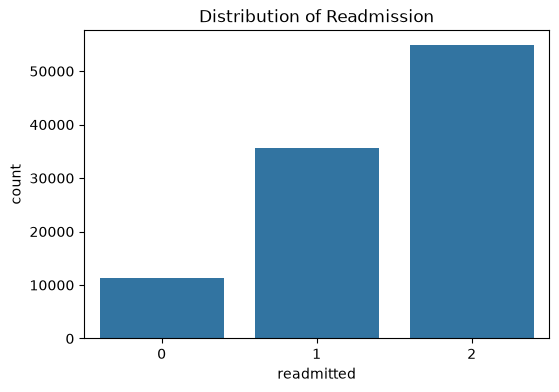

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["readmitted"])
plt.title("Distribution of Readmission")
plt.show()

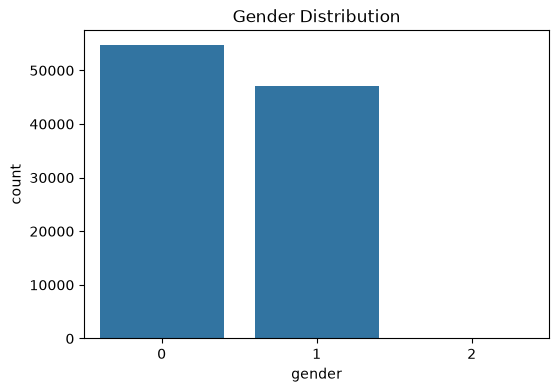

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["gender"])
plt.title("Gender Distribution")
plt.show()

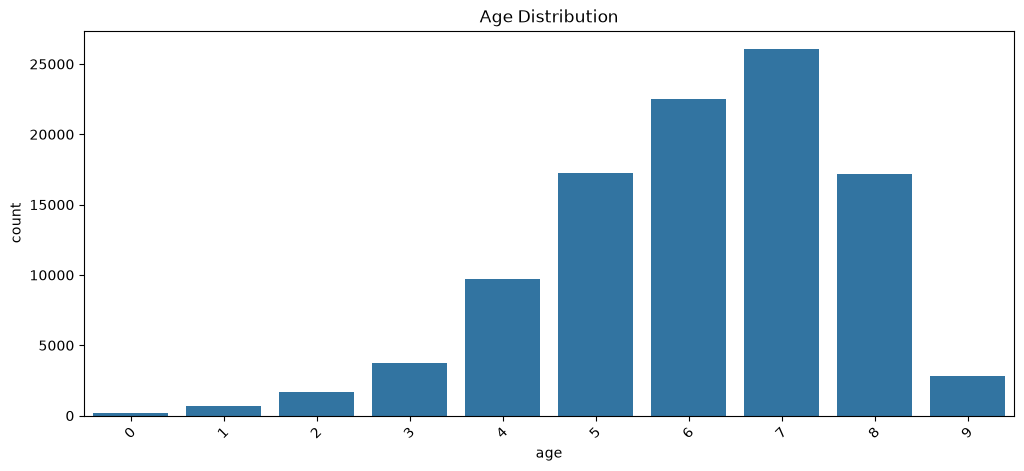

In [20]:
plt.figure(figsize=(12,5))
sns.countplot(x=df["age"])
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

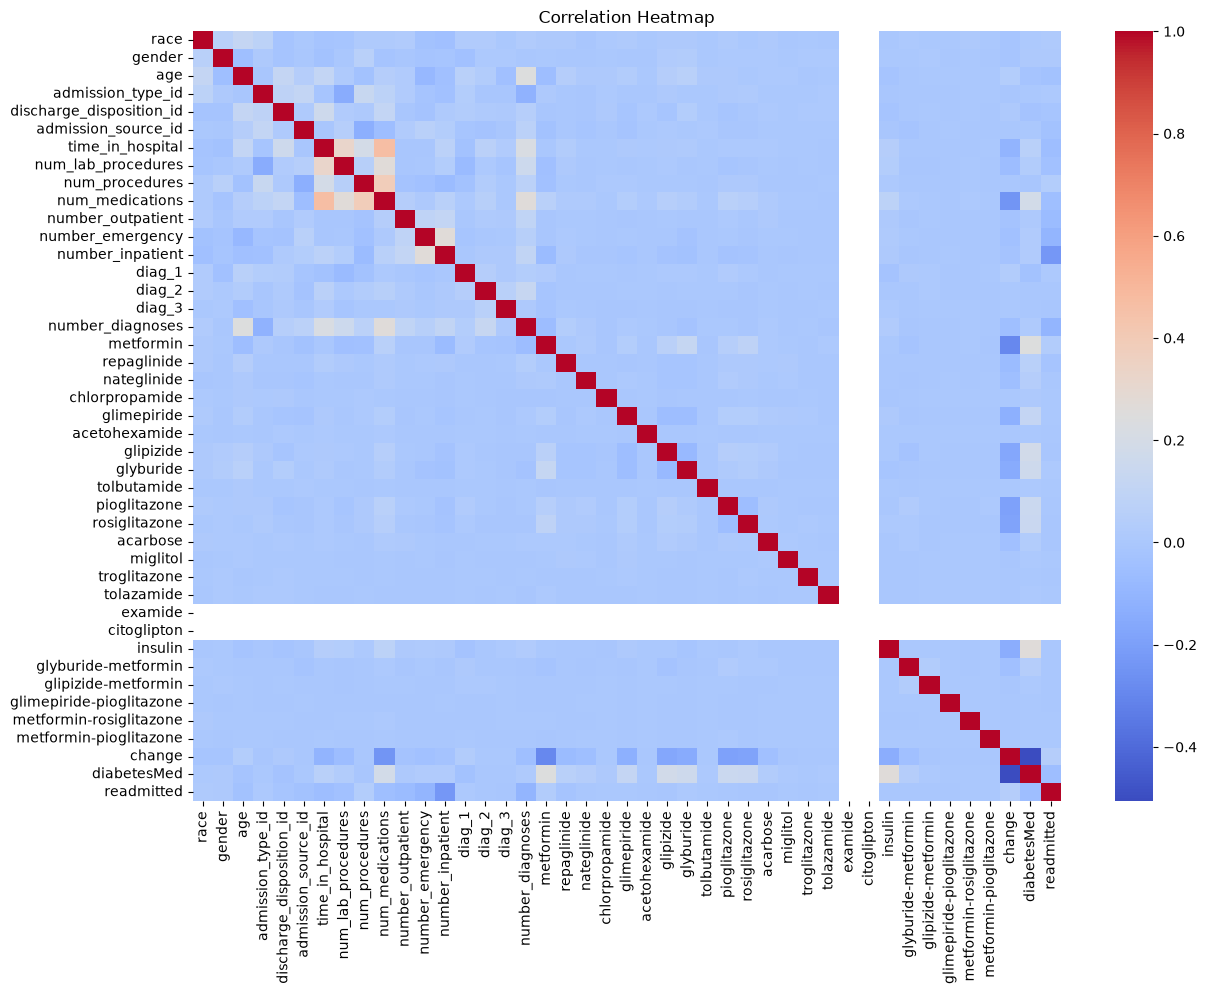

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## 9. Model Building

The cleaned dataset was divided into training and testing datasets.

A Random Forest Classifier was selected as the baseline prediction model.

In [22]:
X = df.drop("readmitted", axis=1)

y = df["readmitted"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(81412, 42)
(20354, 42)


In [24]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.5808686253316302


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.02      0.03      2285
           1       0.49      0.39      0.43      7117
           2       0.62      0.83      0.71     10952

    accuracy                           0.58     20354
   macro avg       0.51      0.41      0.39     20354
weighted avg       0.55      0.58      0.53     20354



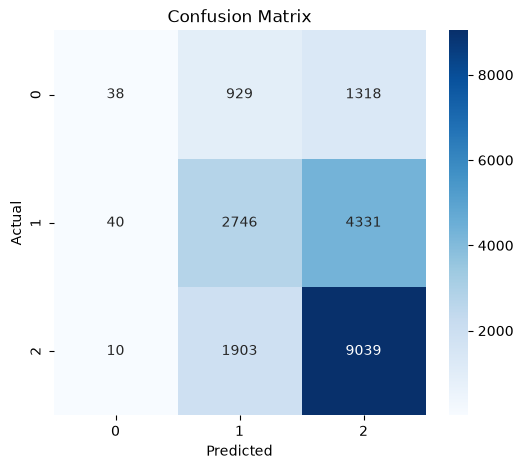

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [29]:
print(df["readmitted"].value_counts())

print("\nPercentage Distribution:\n")

print(df["readmitted"].value_counts(normalize=True) * 100)

readmitted
2    54864
1    35545
0    11357
Name: count, dtype: int64

Percentage Distribution:

readmitted
2    53.911916
1    34.928169
0    11.159916
Name: proportion, dtype: float64


### Hyperparameter Tuning Observation

RandomizedSearchCV was applied to optimize the Random Forest hyperparameters.

The optimized model achieved performance comparable to the baseline model, indicating that the current preprocessing pipeline already provides a strong baseline for this dataset.

In [30]:
print(df.nunique().sort_values(ascending=False))

diag_3                      790
diag_2                      749
diag_1                      717
num_lab_procedures          118
num_medications              75
number_outpatient            39
number_emergency             33
discharge_disposition_id     26
number_inpatient             21
admission_source_id          17
number_diagnoses             16
time_in_hospital             14
age                          10
admission_type_id             8
num_procedures                7
race                          6
glyburide-metformin           4
metformin                     4
repaglinide                   4
nateglinide                   4
chlorpropamide                4
glimepiride                   4
glipizide                     4
pioglitazone                  4
glyburide                     4
acarbose                      4
rosiglitazone                 4
miglitol                      4
insulin                       4
gender                        3
tolazamide                    3
readmitt

## 10. Hyperparameter Tuning

RandomizedSearchCV was used to explore different Random Forest configurations and identify improved model parameters.

In [31]:
from sklearn.model_selection import RandomizedSearchCV

In [32]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [33]:
rf = RandomForestClassifier(random_state=42)

In [34]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [35]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

In [36]:
print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [37]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5852903606170777


## 11. Feature Importance

Random Forest provides feature importance scores that indicate which patient attributes contributed most to readmission prediction.

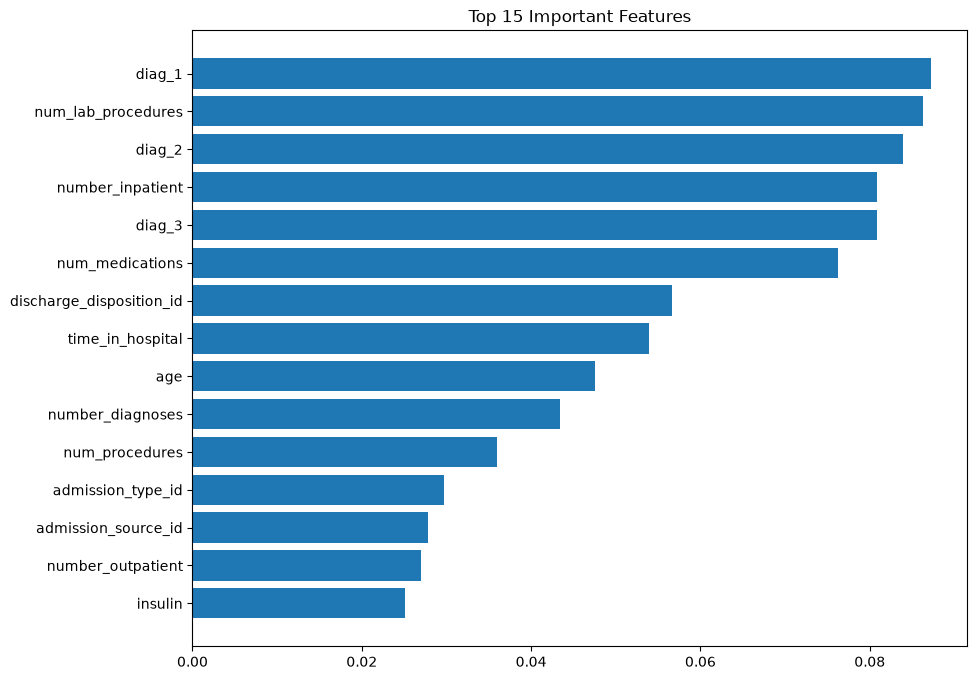

,Feature,Importance
13,diag_1,0.087182
7,num_lab_procedures,0.086256
14,diag_2,0.083911
12,number_inpatient,0.080874
15,diag_3,0.080842
9,num_medications,0.076282
4,discharge_disposition_id,0.056593
6,time_in_hospital,0.053871
2,age,0.047600
16,number_diagnoses,0.043467


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))
plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

feature_importance.head(15)

## 12. Saving Artifacts

The cleaned dataset and trained Random Forest model were saved for future use and deployment.

In [39]:
df.to_csv("../data/processed/cleaned_diabetic_data.csv", index=False)

In [40]:
import joblib

joblib.dump(best_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.01      0.02      2285
           1       0.50      0.36      0.42      7117
           2       0.61      0.85      0.71     10952

    accuracy                           0.59     20354
   macro avg       0.54      0.41      0.38     20354
weighted avg       0.56      0.59      0.53     20354



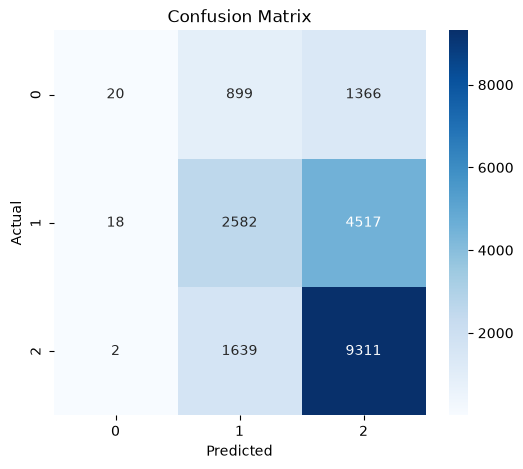

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Conclusion

In this notebook, the Diabetes 130-US Hospitals dataset was successfully preprocessed and analyzed.

Key preprocessing steps included:

- Handling missing values
- Removing highly incomplete features
- Encoding categorical variables
- Removing unnecessary identifier columns
- Checking duplicate records

A Random Forest classifier was trained as the baseline prediction model.

The model achieved approximately **58% classification accuracy** on the testing dataset.

Further improvements such as advanced feature engineering, model optimization, and ensemble learning techniques can be explored in future iterations.